In [8]:
import opendatasets as od
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, ConcatDataset, random_split
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve

In [9]:
# Проверка доступности GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {device}")

Используемое устройство: cpu


**<span style="font-size: 20px;">№1. Загрузка и подготовка данных</span>**

In [10]:
dataset_url = 'https://www.kaggle.com/datasets/sanikamal/horses-or-humans-dataset'
od.download(dataset_url)

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: noirbane
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/sanikamal/horses-or-humans-dataset


100%|██████████| 307M/307M [00:00<00:00, 427MB/s]


In [11]:
data_dir = 'horses-or-humans-dataset/horse-or-human'
train_dir = os.path.join(data_dir, 'train')
validation_dir = os.path.join(data_dir, 'validation')

In [12]:
# Определение трансформаций
IMG_SIZE = 150

# Аугментация изображений для тренировочного набора
augmentation_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.ToTensor()
])

# Базовые трансформации для валидации и тестирования
base_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

print("Трансформации созданы")

Трансформации созданы


In [13]:
# Загрузка датасетов
train_dataset = datasets.ImageFolder(root=train_dir, transform=base_transforms)
val_dataset = datasets.ImageFolder(root=validation_dir, transform=base_transforms)

# Объединяем все данные и разбиваем на train/test (80/20)
all_data = ConcatDataset([train_dataset, val_dataset])
test_size = int(0.2 * len(all_data))
train_size = len(all_data) - test_size
train_dataset_base, test_dataset = random_split(all_data, [train_size, test_size])

# Применяем аугментацию к тренировочным данным
base_dataset = datasets.ImageFolder(root=train_dir, transform=base_transforms)
augmented_datasets = [base_dataset]

# Добавляем 3 аугментированных набора
for _ in range(3):
    aug_dataset = datasets.ImageFolder(root=train_dir, transform=augmentation_transforms)
    augmented_datasets.append(aug_dataset)

# Объединяем все наборы
train_dataset = ConcatDataset(augmented_datasets)

class_names = base_dataset.classes
print(f"Классы: {class_names}")
print(f"Размер тренировочного набора (с аугментацией): {len(train_dataset)}")
print(f"Размер тестового набора: {len(test_dataset)}")

Классы: ['horses', 'humans']
Размер тренировочного набора (с аугментацией): 4108
Размер тестового набора: 256


In [14]:
# Создание DataLoader'ов
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    num_workers=2
)

print(f"DataLoader'ы созданы. Размер батча: {BATCH_SIZE}")

DataLoader'ы созданы. Размер батча: 32


**<span style="font-size: 20px;">№2. Создание модели CNN</span>**

In [ ]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 18 * 18, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = CNN().to(device)
print("Модель CNN создана")
print(model)

Модель CNN создана
CNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=20736, out_features=64, bias=True)
    (2): ReLU()
    

In [17]:
# Инициализация функции потерь и оптимизатора
criterion = nn.BCELoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

print(f"Функция потерь: {criterion.__class__.__name__}")
print(f"Оптимизатор: {optimizer.__class__.__name__}")
print(f"Количество обучаемых параметров: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Функция потерь: BCELoss
Оптимизатор: SGD
Количество обучаемых параметров: 1,351,041


In [18]:
# Функция для обучения одной эпохи
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (data, target) in enumerate(dataloader):
        data, target = data.to(device), target.to(device).float().unsqueeze(1)

        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        predicted = (output > 0.5).float()
        total += target.size(0)
        correct += (predicted == target).sum().item()

    epoch_loss = running_loss / len(dataloader)
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [19]:
# Функция для валидации
def validate_epoch(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_probs = []
    all_targets = []

    with torch.no_grad():
        for data, target in dataloader:
            data, target = data.to(device), target.to(device).float().unsqueeze(1)

            output = model(data)
            loss = criterion(output, target)

            running_loss += loss.item()
            predicted = (output > 0.5).float()
            total += target.size(0)
            correct += (predicted == target).sum().item()

            all_probs.extend(output.cpu().numpy())
            all_targets.extend(target.cpu().numpy())

    epoch_loss = running_loss / len(dataloader)
    epoch_acc = correct / total

    # Вычисляем ROC-AUC
    auc_score = roc_auc_score(all_targets, all_probs)

    return epoch_loss, epoch_acc, auc_score, all_probs, all_targets

**<span style="font-size: 20px;">№3. Обучение модели</span>**

In [ ]:
num_epochs = 10
train_losses = []
val_losses = []
train_accs = []
val_accs = []
auc_scores = []

print("Начало обучения модели...")
print("=" * 50)

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, auc_score, _, _ = validate_epoch(model, test_loader, criterion, device)

    scheduler.step()

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    auc_scores.append(auc_score)

    print(f'Epoch {epoch+1}/{num_epochs}:')
    print(f'  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}')
    print(f'  Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')
    print(f'  ROC-AUC: {auc_score:.4f}')
    print('=' * 50)

print("Обучение завершено!")

Начало обучения модели...
Epoch 1/10:
  Train Loss: 0.3220, Train Acc: 0.8503
  Val Loss: 0.2248, Val Acc: 0.9531
  ROC-AUC: 0.9661
Epoch 2/10:
  Train Loss: 0.1365, Train Acc: 0.9523
  Val Loss: 0.1963, Val Acc: 0.9492
  ROC-AUC: 0.9797
Epoch 3/10:
  Train Loss: 0.1056, Train Acc: 0.9615
  Val Loss: 0.2235, Val Acc: 0.9570
  ROC-AUC: 0.9824
Epoch 4/10:
  Train Loss: 0.0734, Train Acc: 0.9730
  Val Loss: 0.2856, Val Acc: 0.9453
  ROC-AUC: 0.9810
Epoch 5/10:
  Train Loss: 0.0701, Train Acc: 0.9778
  Val Loss: 0.3964, Val Acc: 0.9453
  ROC-AUC: 0.9799
Epoch 6/10:
  Train Loss: 0.0554, Train Acc: 0.9808
  Val Loss: 0.7742, Val Acc: 0.9375
  ROC-AUC: 0.9804
Epoch 7/10:
  Train Loss: 0.0649, Train Acc: 0.9793
  Val Loss: 0.2659, Val Acc: 0.9648
  ROC-AUC: 0.9736
Epoch 8/10:
  Train Loss: 0.0478, Train Acc: 0.9852
  Val Loss: 0.2308, Val Acc: 0.9688
  ROC-AUC: 0.9870
Epoch 9/10:
  Train Loss: 0.0389, Train Acc: 0.9881
  Val Loss: 0.3851, Val Acc: 0.9570
  ROC-AUC: 0.9811
Epoch 10/10:
  Train

**<span style="font-size: 20px;">№4. Визуализация результатов обучения</span>**

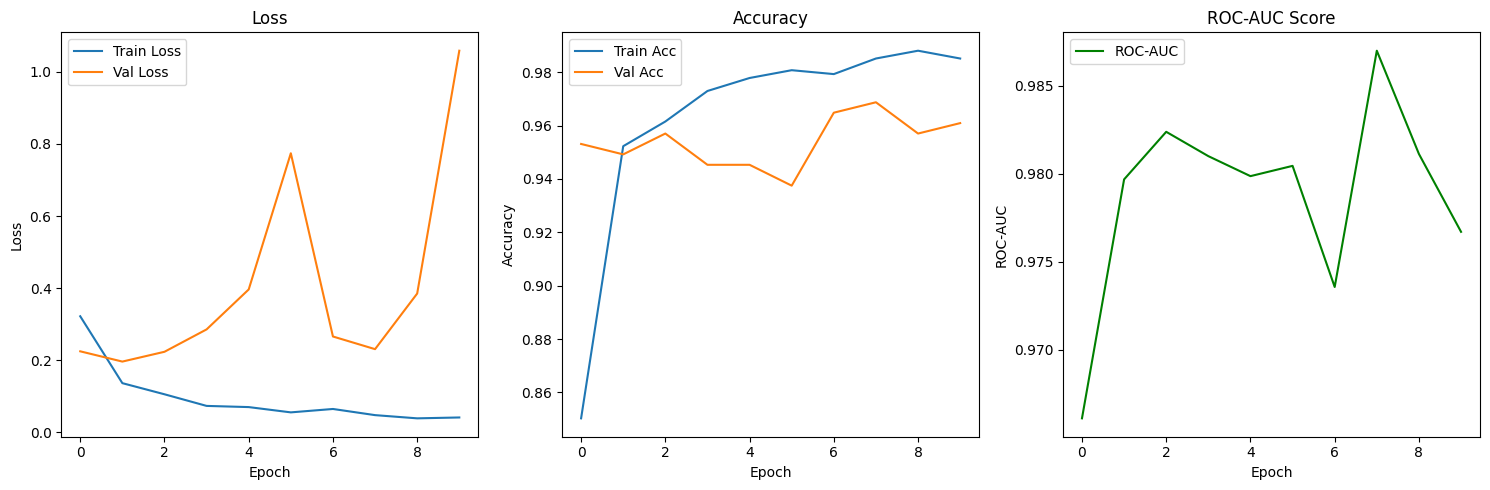

In [ ]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(auc_scores, label='ROC-AUC', color='green')
plt.title('ROC-AUC Score')
plt.xlabel('Epoch')
plt.ylabel('ROC-AUC')
plt.legend()

plt.tight_layout()
plt.show()

**<span style="font-size: 16px;">Финальная оценка модели</span>**

In [ ]:
final_val_loss, final_val_acc, final_auc, all_probs, all_targets = validate_epoch(model, test_loader, criterion, device)

print("=" * 50)
print(f"Финальные результаты на тестовом наборе:")
print(f"  Точность: {final_val_acc:.4f}")
print(f"  Потери: {final_val_loss:.4f}")
print(f"  ROC-AUC: {final_auc:.4f}")
print("=" * 50)

Финальные результаты на тестовом наборе:
  Точность: 0.9609
  Потери: 1.0586
  ROC-AUC: 0.9767


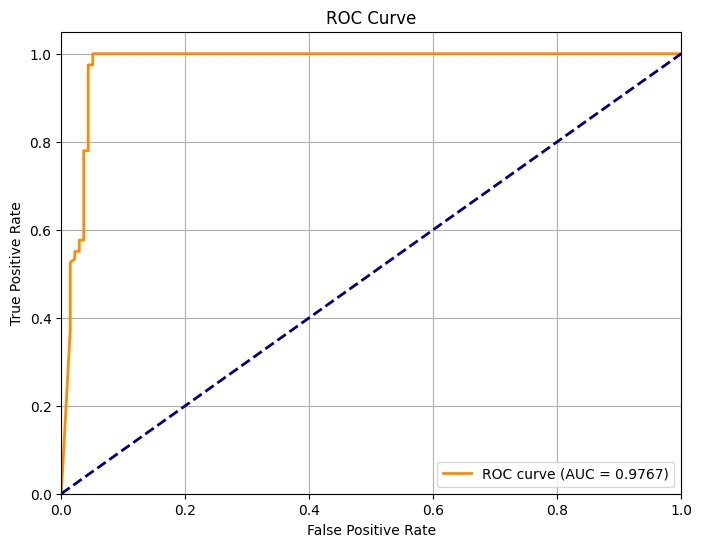

In [ ]:
# Построение ROC-кривой
fpr, tpr, thresholds = roc_curve(all_targets, all_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {final_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [ ]:
# 6. Проверка достижения цели ROC-AUC > 0.6
print("\n" + "="*50)
print("ПРОВЕРКА ВЫПОЛНЕНИЯ ЗАДАНИЯ:")
print(f"Требование: ROC-AUC > 0.6")
print(f"Полученное значение: {final_auc:.4f}")

if final_auc > 0.6:
    print(f"✓ ЦЕЛЬ ДОСТИГНУТА! ROC-AUC > 0.6")
    print("Все пункты лабораторной работы выполнены:")
    print("  1. CNN для бинарной классификации построена ✓")
    print("  2. Датасет загружен ✓")
    print("  3. Аугментация выполнена ✓")
    print("  4. Модель обучена ✓")
    print("  5. ROC-AUC вычислена ✓")
    print("  6. ROC-AUC > 0.6 ✓")
else:
    print(f"✗ ЦЕЛЬ НЕ ДОСТИГНУТА. ROC-AUC ≤ 0.6")

print("="*50)


ПРОВЕРКА ВЫПОЛНЕНИЯ ЗАДАНИЯ:
Требование: ROC-AUC > 0.6
Полученное значение: 0.9767
✓ ЦЕЛЬ ДОСТИГНУТА! ROC-AUC > 0.6
Все пункты лабораторной работы выполнены:
  1. CNN для бинарной классификации построена ✓
  2. Датасет загружен ✓
  3. Аугментация выполнена ✓
  4. Модель обучена ✓
  5. ROC-AUC вычислена ✓
  6. ROC-AUC > 0.6 ✓
